# Care Transition Efficiency & Placement Outcome Analytics

### Business context
Every day, unaccompanied children are apprehended and placed into **CBP (Customs and Border Protection)** custody. From there, they are meant to move into **HHS (Health and Human Services)** care, and finally get placed with a sponsor (family member or guardian).

Right now, most public reporting only shows **snapshot counts** — e.g. "there are 3,000 children in CBP custody today." That tells us *how many*, but not *how well the system is moving people through it*.

This notebook builds a **process efficiency analysis** on top of the raw daily counts, so we can answer:

1. How efficiently are children transferred from CBP to HHS?
2. Are discharges (successful sponsor placements) keeping pace with inflows?
3. When and where do care backlogs accumulate?
4. Are placement outcomes improving or deteriorating over time?

### How this notebook is organized
| Section | What it does |
|---|---|
| 1. Setup | Import the Python libraries we need |
| 2. Load & Clean Data | Read the dataset and prepare it for analysis |
| 3. Pipeline Modelling | Represent CBP → HHS → Sponsor as a flow pipeline |
| 4. Transition Efficiency Metrics | Transfer Efficiency Ratio, Discharge Effectiveness, Throughput Rate |
| 5. Backlog & Delay Identification | Find periods where inflows outpace exits |
| 6. Temporal & Pattern Analysis | Weekday vs weekend, month-over-month trends |
| 7. Outcome Stability Analysis | Volatility and sudden drops in placement success |
| 8. Summary | Plain-English takeaways |

> **Beginner note:** every code cell below is preceded by a markdown cell explaining *what* the code does, *why* it matters for this business problem, and a line-by-line breakdown of any syntax that might be new to you.


## 1. Setup: Importing Libraries

### Why we need this
Python itself doesn't know how to read spreadsheets or draw charts. We need to "import" extra toolkits (called **libraries**) that add this functionality.

### What each library does
- **pandas** (imported as `pd`) — the core toolkit for working with tabular data (rows and columns), similar to Excel but scriptable and much faster for large datasets.
- **numpy** (imported as `np`) — provides fast math operations, especially useful for handling missing values and calculations across many rows at once.
- **matplotlib.pyplot** (imported as `plt`) — draws charts (line charts, bar charts, etc.).
- **seaborn** (imported as `sns`) — sits on top of matplotlib and makes charts look more polished with less code.

### Syntax breakdown
- `import pandas as pd` — loads the `pandas` library and gives it the short nickname `pd`, so instead of typing `pandas.read_csv(...)` everywhere, we just type `pd.read_csv(...)`.
- `%matplotlib inline` — a special Jupyter-only command (called a "magic command", note the `%`) that tells the notebook to display charts directly below the code cell, instead of in a separate window.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes charts appear directly inside the notebook
%matplotlib inline

# Makes charts a readable size by default
plt.rcParams['figure.figsize'] = (12, 5)

# Sets a clean visual style for all charts in this notebook
sns.set_style('whitegrid')

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Clean the Data

### Business context
We're working with daily records that track children moving through three stages:
1. **CBP custody** (apprehension and initial holding)
2. **HHS care** (longer-term care while a sponsor is found)
3. **Sponsor placement** (the successful "exit" of the pipeline)

### Expected columns
Rename your raw file's columns to match the names below (or edit the `rename` dictionary in the code to match your actual column headers).

| Standardized column name | Original column description |
|---|---|
| `Date` | Date of reporting |
| `cbp_intake` | Children apprehended and placed in CBP custody (daily intake volume) |
| `cbp_custody` | Children in CBP custody (active CBP care load) |
| `cbp_to_hhs_transfer` | Children transferred out of CBP custody (flow into HHS) |
| `hhs_care` | Children in HHS Care (active HHS care load) |
| `hhs_discharge` | Children discharged from HHS Care (successful sponsor placements) |

### Syntax breakdown
- `pd.read_csv('file.csv')` — reads a CSV file into a **DataFrame**, which is pandas' name for a table (rows + columns).
- `df.rename(columns={...})` — relabels columns. The dictionary `{'old_name': 'new_name'}` maps what your file currently calls a column to what we want to call it going forward.
- `pd.to_Datetime(df['Date'])` — converts a text column like `"2024-01-05"` into an actual Date object, so pandas understands it as a calendar Date (not just a string) and can do things like "sort chronologically" or "group by month."
- `df.sort_values('Date')` — orders all rows from earliest to latest Date, which matters for any time-based ("temporal") analysis.
- `df.isna().sum()` — counts missing values in each column. `isna()` flags each cell as `True` (missing) or `False` (present); `sum()` adds up the `True` values (Python treats `True` as 1).
- `df.fillna(method='ffill')` — "forward fill": replaces a missing value with the last known value before it. This is a common, defensible choice for daily custody counts, since a missing day's count is more sensibly estimated from the prior day than left blank or set to zero.


In [2]:
# --- STEP 1: Load your data ---
# Replace 'care_transition_data.csv' with the actual path to your file
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")


In [3]:
 
# --- STEP 1: Load your dataset ---
df = pd.read_csv('HHS_Unaccompanied_Alien_Children_Program.csv')

# --- STEP 2: Check how many missing values exist, per column ---
print("Missing values per column before cleaning:")
print(df.isna().sum())

# --- STEP 3: Remove rows with any missing/null value ---
# (Date column is untouched -- no parsing, formatting, or conversion happens here)
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"\nRows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

# --- STEP 4: Save the cleaned data to a new CSV file ---
df.to_csv('HHS_Unaccompanied_Alien_Children_Program_cleaned.csv', index=False)

print("\nSaved cleaned file as 'HHS_Unaccompanied_Alien_Children_Program_cleaned.csv'")

Missing values per column before cleaning:
Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

Rows before: 1170
Rows after:  720
Rows removed: 450

Saved cleaned file as 'HHS_Unaccompanied_Alien_Children_Program_cleaned.csv'


In [4]:
df

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0
...,...,...,...,...,...,...
715,"January 25, 2023",20.0,22.0,41.0,"7,538",180.0
716,"January 24, 2023",47.0,42.0,47.0,"7,433",175.0
717,"January 23, 2023",32.0,50.0,39.0,"7,280",181.0
718,"January 22, 2023",32.0,49.0,39.0,"7,122",227.0


In [5]:
df['Date'].head(2)

0    December 21, 2025
1    December 18, 2025
Name: Date, dtype: str

In [6]:


# --- STEP 2: Standardize column names ---

# Edit the left-hand side (old names) to match your actual file's headers

df = df.rename(columns={

    'Date of reporting': 'Date',

    'Children apprehended and placed in CBP custody*': 'cbp_intake',

    'Children in CBP custody': 'cbp_custody',

    'Children transferred out of CBP custody': 'cbp_to_hhs_transfer',

    'Children in HHS Care': 'hhs_care',

    'Children discharged from HHS Care': 'hhs_discharge'

})


In [7]:
df.columns

Index(['Date', 'cbp_intake', 'cbp_custody', 'cbp_to_hhs_transfer', 'hhs_care',
       'hhs_discharge'],
      dtype='str')

In [8]:
# --- STEP 3.a: Convert the Date column to a real Date type ---
df['Date'] = pd.to_datetime(df['Date'],format='%B %d, %Y')

In [ ]:
pip install missingno

In [10]:
df.tail(20)

,Date,cbp_intake,cbp_custody,cbp_to_hhs_transfer,hhs_care,hhs_discharge
700,2023-02-16,81.0,213.0,153.0,"7,793",361.0
701,2023-02-15,91.0,199.0,172.0,"7,869",290.0
702,2023-02-14,154.0,225.0,220.0,"7,794",223.0
703,2023-02-13,186.0,259.0,172.0,"7,483",244.0
704,2023-02-12,92.0,203.0,173.0,"7,434",317.0
705,2023-02-09,124.0,234.0,161.0,"7,908",353.0
706,2023-02-08,93.0,196.0,169.0,"7,915",317.0
707,2023-02-07,16.0,20.0,20.0,"7,855",200.0
708,2023-02-06,11.0,22.0,12.0,"7,720",196.0
709,2023-02-05,16.0,18.0,15.0,"7,586",342.0


<Figure size 1200x600 with 0 Axes>

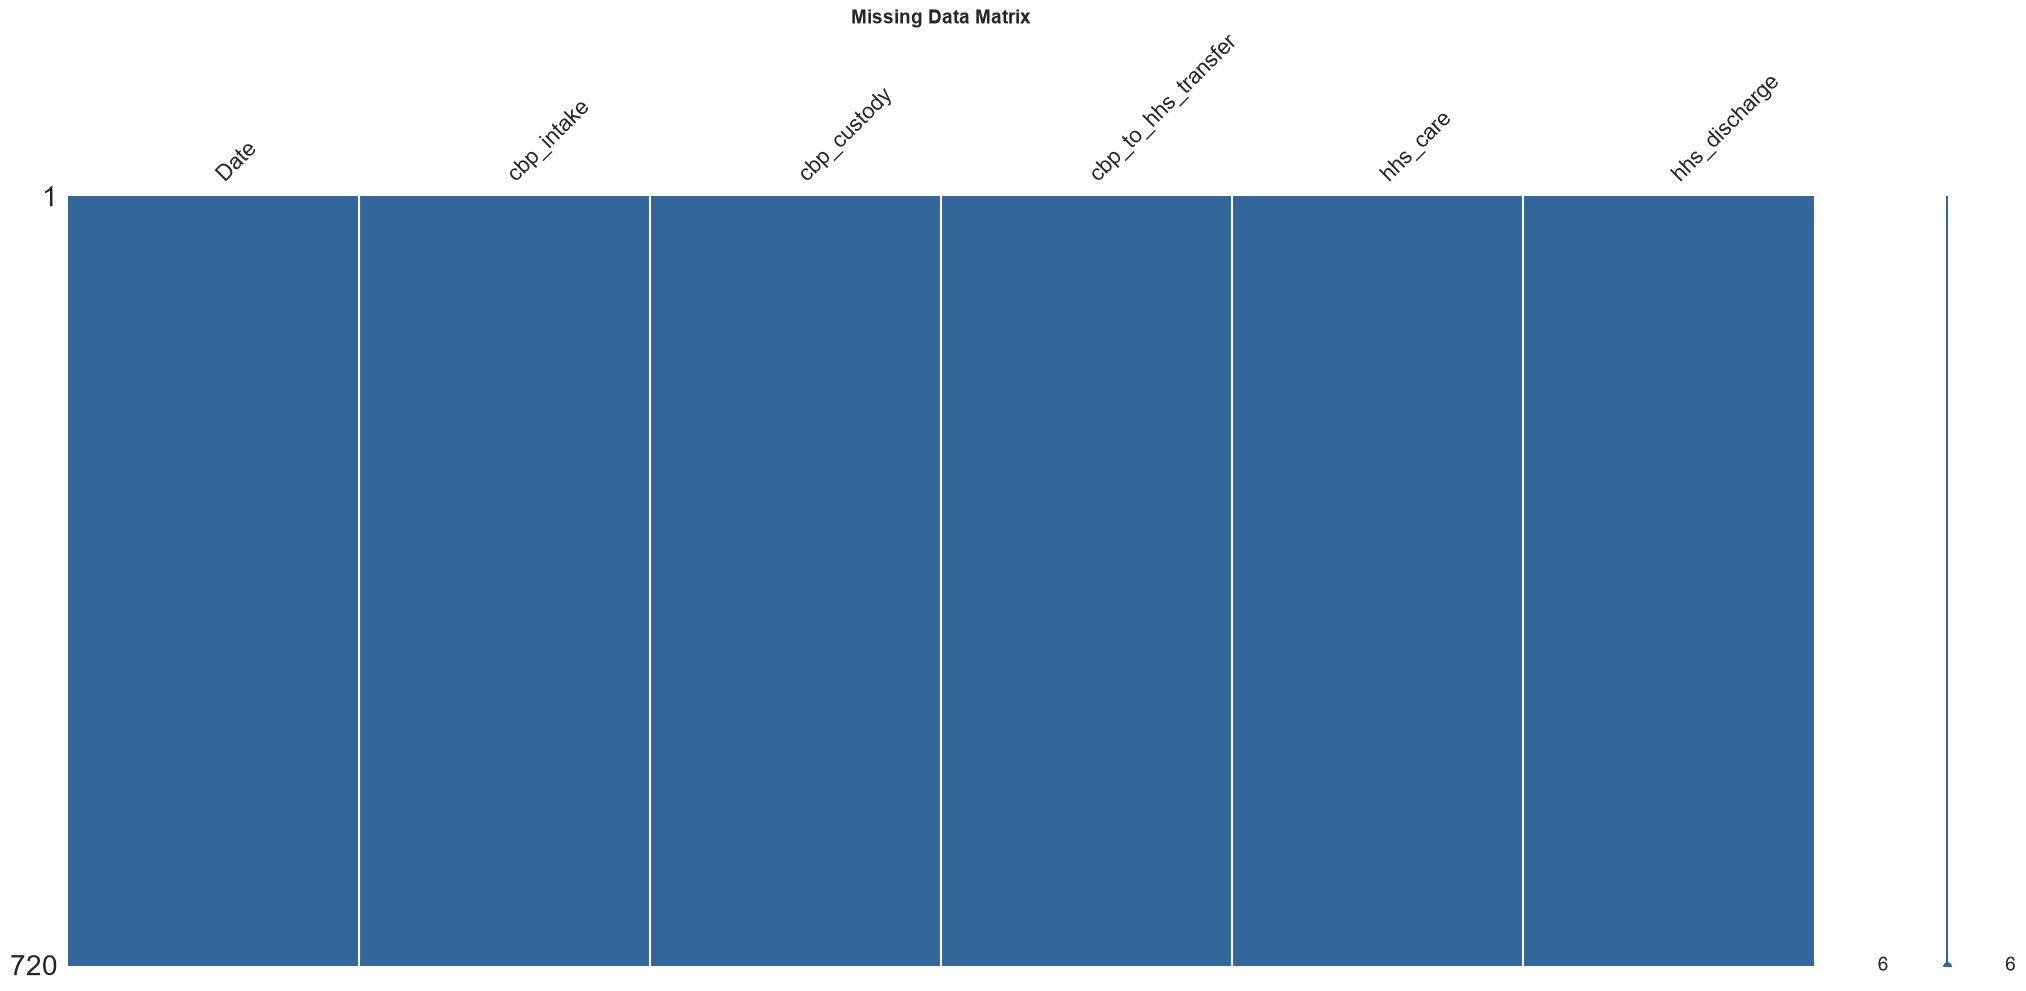

In [11]:
import missingno as msno
# 2. Matrix plot to see data completeness patterns
plt.figure(figsize=(12,6))
msno.matrix(df, color=(0.2, 0.4, 0.6))
plt.title("Missing Data Matrix", fontsize=14, weight='bold')
plt.show()

In [12]:
# --- 3.b. WRITE: Convert the Datetime object into your desired "DD-MM-YYYY" string format
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')


In [13]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 720 non-null    datetime64[us]
 1   cbp_intake           720 non-null    float64       
 2   cbp_custody          720 non-null    float64       
 3   cbp_to_hhs_transfer  720 non-null    float64       
 4   hhs_care             720 non-null    str           
 5   hhs_discharge        720 non-null    float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 33.9 KB


In [15]:
# --- STEP 4: Sort chronologically (oldest to newest) ---
df = df.sort_values('Date').reset_index(drop=True)

In [16]:
# --- STEP 5: Check for missing values ---
print("Missing values per column:")
df.isna().sum()

Missing values per column:


Date                   0
cbp_intake             0
cbp_custody            0
cbp_to_hhs_transfer    0
hhs_care               0
hhs_discharge          0
dtype: int64

**NOTE:**
The missing values in this dataset has more than 38% so we have to removed because if we input a large number of thing so  the data might show us misleading.

In [17]:
df.shape

(720, 6)

In [18]:
df = df.dropna(axis=0, how='all')

In [19]:
df.shape

(720, 6)

In [20]:
# --- STEP 7: Preview the cleaned data ---
df.head()


,Date,cbp_intake,cbp_custody,cbp_to_hhs_transfer,hhs_care,hhs_discharge
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


## 3. Pipeline Modelling: CBP → HHS → Sponsor

### Business context
Think of the system as **water flowing through three connected tanks**:

```
[ CBP custody ] --transfer--> [ HHS care ] --discharge--> [ Sponsor placement ]
      ^                              
      |                              
   new intake                        
```

- Water flows **in** to CBP custody (new apprehensions).
- Water flows **out** of CBP custody and **into** HHS care (transfers).
- Water flows **out** of HHS care via successful discharges (sponsor placements).

If water flows in faster than it flows out of any tank, that tank's water level (the backlog) rises. Our job is to measure the *flow rates*, not just the *water level* at any one moment.

### Syntax breakdown
- `df['new_column'] = df['col_a'] - df['col_b']` — creates a new column by doing row-by-row arithmetic. Pandas automatically applies this to every row, so we don't need a manual loop.
- `.cumsum()` — "cumulative sum": running total of a column from the first row down to the current row. Useful for tracking total children processed over time.


In [21]:
# Net daily change in each stage's holding population
# A positive number means the "tank" is filling up (backlog building)
# A negative number means the "tank" is draining (backlog clearing)

df['cbp_net_change'] = df['cbp_intake'] - df['cbp_to_hhs_transfer']
df['hhs_net_change'] = df['cbp_to_hhs_transfer'] - df['hhs_discharge']

# Cumulative totals: how many children have moved through each stage so far
df['cumulative_intake'] = df['cbp_intake'].cumsum()
df['cumulative_transfers'] = df['cbp_to_hhs_transfer'].cumsum()
df['cumulative_discharges'] = df['hhs_discharge'].cumsum()

df[['Date', 'cbp_net_change', 'hhs_net_change']].head()


,Date,cbp_net_change,hhs_net_change
0,2023-01-12,-1.0,-402.0
1,2023-01-22,-7.0,-188.0
2,2023-01-23,-7.0,-142.0
3,2023-01-24,0.0,-128.0
4,2023-01-25,-21.0,-139.0


**How to read `cbp_net_change` and `hhs_net_change`:**
- `cbp_net_change > 0` → more children entered CBP custody than were transferred out that day → CBP backlog is growing.
- `hhs_net_change > 0` → more children were transferred into HHS than discharged that day → HHS backlog is growing.
- Values near zero mean the stage is roughly "keeping pace."


## 4. Transition Efficiency Metrics

### Business context
These three ratios are the heart of the analysis. They convert raw counts into **rates**, which is what lets us compare efficiency across different days, months, or custody-volume levels — a day with 5,000 children in custody isn't automatically "worse" than a day with 500; what matters is what *fraction* moved through.

| Metric | Formula | What it tells us |
|---|---|---|
| **Transfer Efficiency Ratio** | Transfers ÷ CBP Custody | What share of the CBP population is being moved to HHS each day |
| **Discharge Effectiveness** | Discharges ÷ HHS Care | What share of the HHS population is successfully placed with sponsors each day |
| **Pipeline Throughput Rate** | Total Exits ÷ Total Entries | Whether the whole pipeline is draining as fast as it's filling, system-wide |

A ratio near **1.0** (or 100%) means the system is processing cases about as fast as they arrive. A ratio well below 1.0 signals a bottleneck.

### Syntax breakdown
- `df['a'] / df['b']` — divides column `a` by column `b`, row by row.
- `.replace([np.inf, -np.inf], np.nan)` — after dividing, if a denominator was 0, pandas produces `inf` (infinity), which isn't meaningful here. This line replaces those infinite values with `NaN` (Not a Number / missing), so they don't distort averages or charts.
- `.round(3)` — rounds a number to 3 decimal places, purely for readability.


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   720 non-null    datetime64[us]
 1   cbp_intake             720 non-null    float64       
 2   cbp_custody            720 non-null    float64       
 3   cbp_to_hhs_transfer    720 non-null    float64       
 4   hhs_care               720 non-null    str           
 5   hhs_discharge          720 non-null    float64       
 6   cbp_net_change         720 non-null    float64       
 7   hhs_net_change         720 non-null    float64       
 8   cumulative_intake      720 non-null    float64       
 9   cumulative_transfers   720 non-null    float64       
 10  cumulative_discharges  720 non-null    float64       
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 62.0 KB


In [23]:
df['hhs_care'].head()

0    6,566
1    7,122
2    7,280
3    7,433
4    7,538
Name: hhs_care, dtype: str

In [24]:
# Remove commas (and/or $ signs) first
df['hhs_care'] = df['hhs_care'].str.replace(',', '', regex=False)

# Then convert to float
df['hhs_care'] = pd.to_numeric(df['hhs_care'], errors='coerce')

In [25]:
# Transfer Efficiency Ratio: how much of the CBP custody load is transferred out per day
df['transfer_efficiency_ratio'] = (df['cbp_to_hhs_transfer'] / df['cbp_custody']).replace([np.inf, -np.inf], np.nan).round(3)

# Discharge Effectiveness: how much of the HHS care load is discharged per day
df['discharge_effectiveness'] = (df['hhs_discharge'] / df['hhs_care']).replace([np.inf, -np.inf], np.nan).round(3)

# Pipeline Throughput Rate: total exits (discharges) vs total entries (intake) -- system-wide balance
df['pipeline_throughput_rate'] = (df['hhs_discharge'] / df['cbp_intake']).replace([np.inf, -np.inf], np.nan).round(3)

df[['Date', 'transfer_efficiency_ratio', 'discharge_effectiveness', 'pipeline_throughput_rate']].head(10)


,Date,transfer_efficiency_ratio,discharge_effectiveness,pipeline_throughput_rate
0,2023-01-12,0.642,0.066,13.212
1,2023-01-22,0.796,0.032,7.094
2,2023-01-23,0.780,0.025,5.656
3,2023-01-24,1.119,0.024,3.723
4,2023-01-25,1.864,0.024,9.000
5,2023-01-29,0.244,0.041,13.174
6,2023-01-30,0.537,0.025,5.765
7,2023-01-31,1.000,0.020,6.077
8,2023-02-01,0.844,0.029,9.240
9,2023-02-02,1.769,0.038,19.867


### Visualizing the efficiency metrics over time

This chart plots all three ratios on the same axes so we can see, at a glance, which stage of the pipeline is lagging.


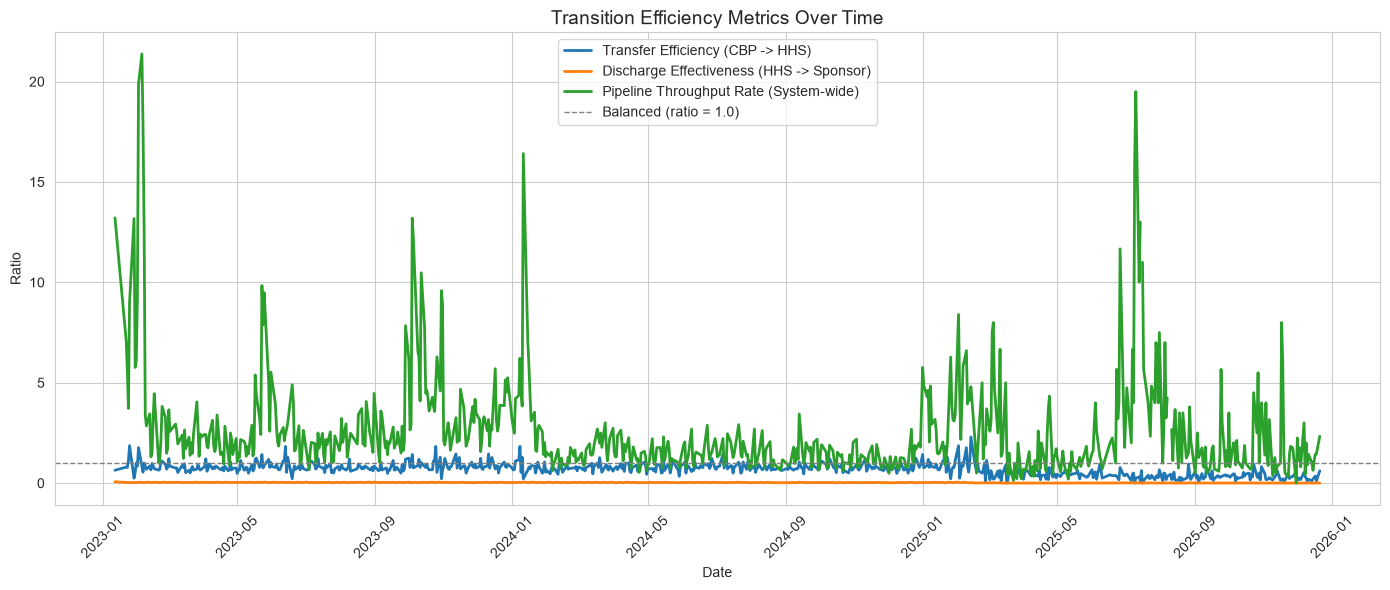

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Date'], df['transfer_efficiency_ratio'], label='Transfer Efficiency (CBP -> HHS)', linewidth=2)
ax.plot(df['Date'], df['discharge_effectiveness'], label='Discharge Effectiveness (HHS -> Sponsor)', linewidth=2)
ax.plot(df['Date'], df['pipeline_throughput_rate'], label='Pipeline Throughput Rate (System-wide)', linewidth=2)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Balanced (ratio = 1.0)')

ax.set_title('Transition Efficiency Metrics Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Ratio')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**How to read this chart:** the dashed gray line at 1.0 marks a "balanced" system. Any line that sits consistently **below** 1.0 shows that stage isn't keeping pace with what's flowing in — that's your bottleneck.

## 5. Backlog & Delay Identification

### Business context
A single bad day doesn't necessarily mean a systemic problem — it could be noise (a holiday, a data glitch). What matters is **sustained imbalance**: several days or weeks in a row where inflows exceed exits. That's the signature of a real, accumulating backlog.

### Approach
1. Compute a rolling (moving) average of net change, to smooth out single-day noise.
2. Flag any day where the rolling average is positive (backlog building) for several consecutive days.
3. Count and visualize these "backlog periods."

### Syntax breakdown
- `.rolling(window=7).mean()` — computes the average of each value and the 6 values before it (a 7-day moving average), smoothing out day-to-day noise so we can see the underlying trend.
- `np.where(condition, value_if_true, value_if_false)` — a row-by-row "if/else": for each row, check `condition`; if true, use `value_if_true`, otherwise use `value_if_false`.
- `.diff()` — calculates the difference between each row and the row before it. We use this to detect when a backlog *starts* (flag switches from 0 to 1) versus continues.
- `.cumsum()` on a boolean "start" flag — because `True` counts as 1 and `False` as 0, running a cumulative sum over "backlog start" flags gives each distinct backlog stretch its own increasing ID number, which we can then group by.


In [27]:
# 7-day rolling average of net change, to smooth daily noise
df['hhs_backlog_trend'] = df['hhs_net_change'].rolling(window=7, min_periods=1).mean()
df['cbp_backlog_trend'] = df['cbp_net_change'].rolling(window=7, min_periods=1).mean()

# Flag days where the HHS backlog trend is building (positive rolling average)
df['hhs_backlog_flag'] = np.where(df['hhs_backlog_trend'] > 0, 1, 0)

# Identify distinct backlog "episodes" (consecutive runs of flagged days)
df['hhs_backlog_episode_start'] = (df['hhs_backlog_flag'].diff() == 1)
df['hhs_backlog_episode_id'] = df['hhs_backlog_episode_start'].cumsum()

# Only keep episode IDs where the flag is actually active
backlog_days = df[df['hhs_backlog_flag'] == 1]
episode_lengths = backlog_days.groupby('hhs_backlog_episode_id').size()

print(f"Number of distinct sustained HHS backlog episodes: {episode_lengths.shape[0]}")
print(f"Longest sustained backlog episode: {episode_lengths.max() if len(episode_lengths) > 0 else 0} days")
print(f"Average backlog episode length: {episode_lengths.mean():.1f} days" if len(episode_lengths) > 0 else "No backlog episodes detected")


Number of distinct sustained HHS backlog episodes: 22
Longest sustained backlog episode: 61 days
Average backlog episode length: 11.4 days


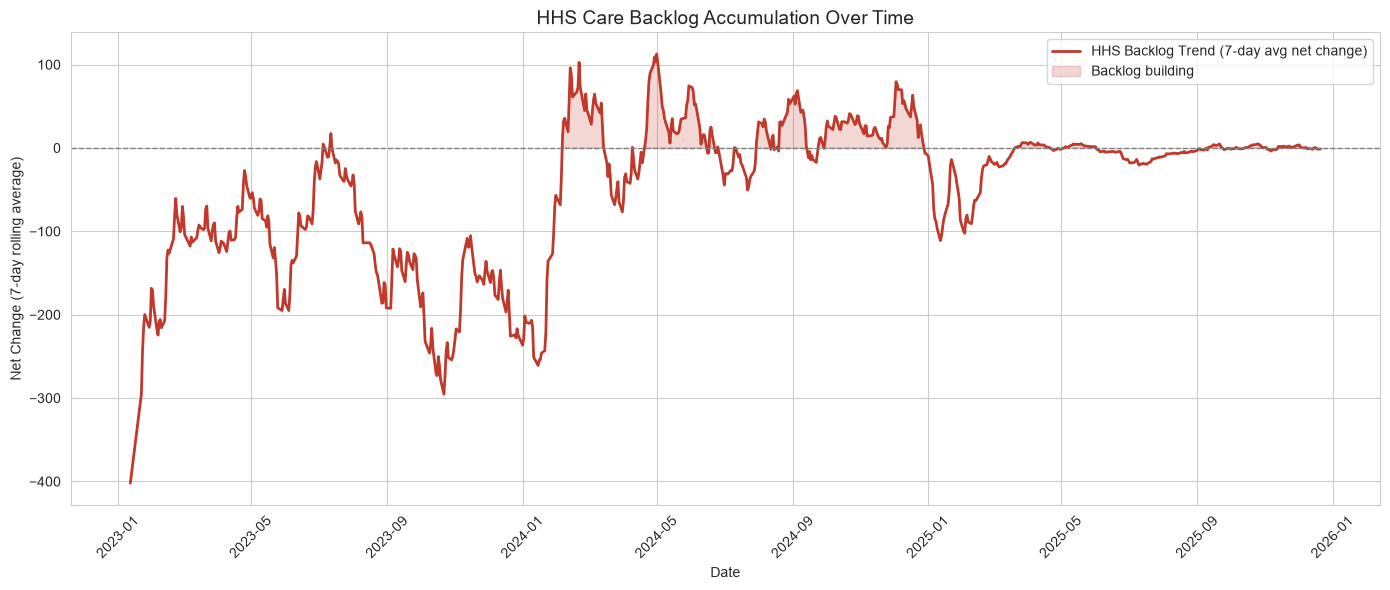

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['Date'], df['hhs_backlog_trend'], color='#c0392b', linewidth=2, label='HHS Backlog Trend (7-day avg net change)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.fill_between(df['Date'], df['hhs_backlog_trend'], 0,
                 where=(df['hhs_backlog_trend'] > 0),
                 color='#c0392b', alpha=0.2, label='Backlog building')
ax.set_title('HHS Care Backlog Accumulation Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Net Change (7-day rolling average)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
# Save the figure in HD
#plt.savefig("Bscklog & Delay Identification.png", dpi=300, bbox_inches="tight")
plt.show()


**How to read this chart:** the shaded red areas mark periods where, on average over the trailing week, more children entered HHS care than were discharged — i.e. sustained backlog accumulation, not just single-day noise.

## 6. Temporal & Pattern Analysis

### Business context
Government processing often slows down on weekends and holidays (fewer caseworkers, courts closed, etc.). If discharges and transfers systematically drop on weekends, that's a *process* issue we can point to directly, rather than a mysterious dip.

We'll look at:
- **Weekday vs weekend** transition speed
- **Month-over-month** placement trends
- **Prolonged stagnation periods** (stretches with near-zero discharge activity)

### Syntax breakdown
- `df['Date'].dt.day_name()` — extracts the name of the weekday (e.g. "Monday") from a Date. The `.dt` accessor unlocks Date-specific operations on a Datetime column.
- `df['Date'].dt.dayofweek` — gives the weekday as a number (0 = Monday ... 6 = Sunday). We use this to classify days as weekday vs weekend.
- `.isin([5, 6])` — checks whether a value is in the given list (5 = Saturday, 6 = Sunday), returning `True`/`False` per row.
- `df.groupby('column').mean()` — splits the data into groups based on a column's values (e.g. "Weekday" vs "Weekend"), then computes the average of other columns within each group.
- `df['Date'].dt.to_period('M')` — converts each Date into its containing month (e.g. `2024-01-15` becomes `2024-01`), which lets us group daily rows into monthly buckets.


In [29]:
# Add weekday name and weekday/weekend flag
df['day_of_week'] = df['Date'].dt.day_name()
df['is_weekend'] = df['Date'].dt.dayofweek.isin([5, 6])
df['day_type'] = np.where(df['is_weekend'], 'Weekend', 'Weekday')

# Compare average efficiency metrics: weekday vs weekend
weekday_vs_weekend = df.groupby('day_type')[[
    'transfer_efficiency_ratio', 'discharge_effectiveness', 'pipeline_throughput_rate'
]].mean().round(3)

print("Average efficiency: Weekday vs Weekend")
weekday_vs_weekend


Average efficiency: Weekday vs Weekend


,transfer_efficiency_ratio,discharge_effectiveness,pipeline_throughput_rate
day_type,,,
Weekday,0.689,0.023,2.465
Weekend,0.700,0.028,2.677


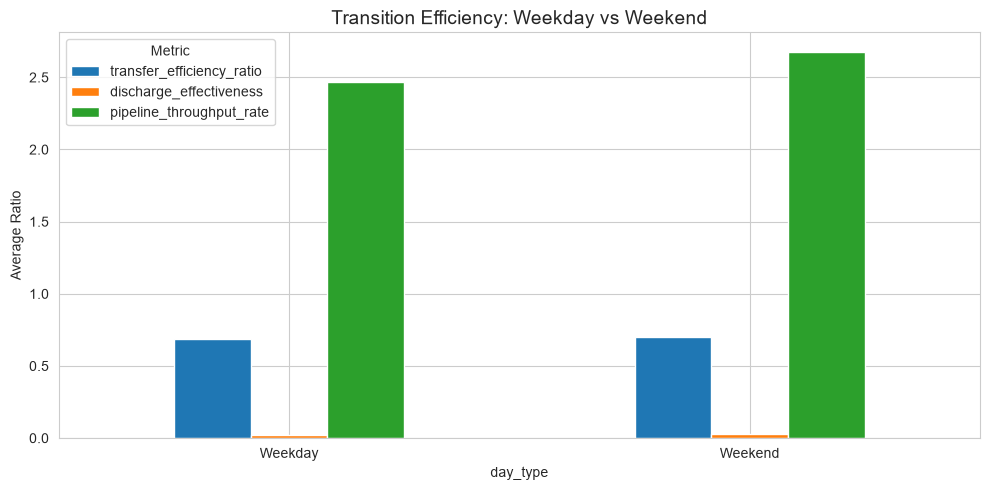

In [30]:
# Bar chart: weekday vs weekend comparison
weekday_vs_weekend.plot(kind='bar', figsize=(10, 5))
plt.title('Transition Efficiency: Weekday vs Weekend', fontsize=14)
plt.ylabel('Average Ratio')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


**How to read this:** if the "Weekend" bars are noticeably shorter than the "Weekday" bars, that confirms transitions genuinely slow down on weekends — a concrete, actionable operational finding (e.g. staffing levels).

In [31]:
# Month-over-month placement (discharge) trend
df['year_month'] = df['Date'].dt.to_period('M')

monthly_summary = df.groupby('year_month').agg(
    total_intake=('cbp_intake', 'sum'),
    total_transfers=('cbp_to_hhs_transfer', 'sum'),
    total_discharges=('hhs_discharge', 'sum'),
    avg_discharge_effectiveness=('discharge_effectiveness', 'mean')
).round(2)

monthly_summary


,total_intake,total_transfers,total_discharges,avg_discharge_effectiveness
year_month,,,,
2023-01,247.0,276.0,1856.0,0.03
2023-02,1886.0,2637.0,5183.0,0.04
2023-03,2479.0,3399.0,5375.0,0.04
2023-04,3129.0,3967.0,5668.0,0.03
2023-05,2746.0,3622.0,6256.0,0.03
2023-06,1774.0,2416.0,4029.0,0.03
2023-07,2858.0,3897.0,4407.0,0.03
2023-08,2751.0,3587.0,6470.0,0.03
2023-09,3194.0,3971.0,6546.0,0.03


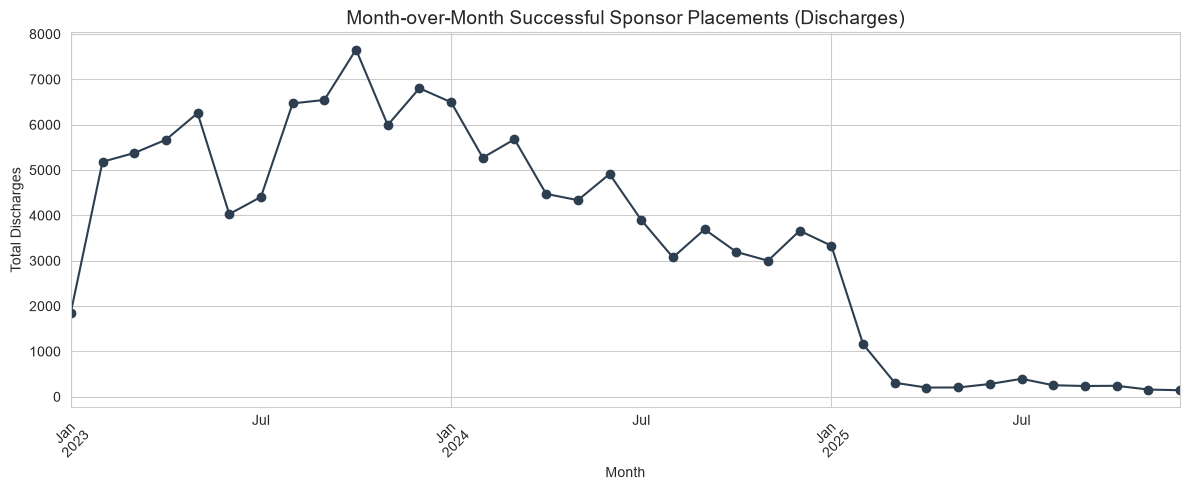

In [ ]:
# Visualize month-over-month discharge trend
monthly_summary['total_discharges'].plot(kind='line', marker='o', figsize=(12, 5), color='#2c3e50')
plt.title('Month-over-Month Successful Sponsor Placements (Discharges)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Discharges')
plt.xticks(rotation=45)
plt.tight_layout()
# Save the figure in HD
#plt.savefig("Month-over-month discharge .png", dpi=300, bbox_inches="tight")
plt.show()


### Detecting prolonged stagnation periods

A "stagnation period" is a stretch of consecutive days where discharge effectiveness stays below a low threshold (meaning almost nobody is being placed with sponsors relative to the HHS care load).

**Syntax breakdown:**
- We reuse the same "flag + `.diff()` + `.cumsum()`" pattern from the backlog section above, this time applied to a *low discharge effectiveness* condition instead of a *positive net change* condition. This is a reusable technique: any time you want to find "how many consecutive days did X happen," this pattern works.


In [33]:
STAGNATION_THRESHOLD = 0.05  # Adjust based on what counts as "meaningfully low" for your data

df['stagnation_flag'] = np.where(df['discharge_effectiveness'] < STAGNATION_THRESHOLD, 1, 0)
df['stagnation_episode_start'] = (df['stagnation_flag'].diff() == 1)
df['stagnation_episode_id'] = df['stagnation_episode_start'].cumsum()

stagnation_days = df[df['stagnation_flag'] == 1]
stagnation_lengths = stagnation_days.groupby('stagnation_episode_id').size()

if len(stagnation_lengths) > 0:
    print(f"Number of stagnation episodes: {len(stagnation_lengths)}")
    print(f"Longest stagnation episode: {stagnation_lengths.max()} days")
else:
    print("No stagnation episodes detected at this threshold.")


Number of stagnation episodes: 5
Longest stagnation episode: 481 days


## 7. Outcome Stability Analysis

### Business context
Even if the *average* discharge rate looks fine, a system that swings wildly between "great week" and "terrible week" is not actually reliable. Stability matters as much as the average, especially for a process that affects vulnerable children waiting to be placed.

We'll measure:
- **Variability** in discharge performance (standard deviation, coefficient of variation)
- **Consistency** of placement outcomes month to month
- **Sudden drops** in reunification/placement success (statistical outliers on the downside)

### Syntax breakdown
- `.std()` — standard deviation: on average, how far individual values stray from the mean. A bigger number means more day-to-day volatility.
- **Coefficient of Variation (CV)** = standard deviation ÷ mean. This standardizes volatility so it's comparable across metrics with different scales (e.g. comparing volatility of a 0–1 ratio to volatility of a raw count wouldn't otherwise be meaningful).
- `.mean()` and `.std()` used together to define a "normal range," then flagging points that fall far outside it (commonly more than 2 standard deviations below the mean) as a **sudden drop**.


In [34]:
# Overall variability in discharge effectiveness
mean_discharge_eff = df['discharge_effectiveness'].mean()
std_discharge_eff = df['discharge_effectiveness'].std()
cv_discharge_eff = std_discharge_eff / mean_discharge_eff

print(f"Average discharge effectiveness: {mean_discharge_eff:.3f}")
print(f"Standard deviation: {std_discharge_eff:.3f}")
print(f"Coefficient of Variation: {cv_discharge_eff:.2f}  (higher = less stable/predictable)")


Average discharge effectiveness: 0.024
Standard deviation: 0.013
Coefficient of Variation: 0.56  (higher = less stable/predictable)


In [35]:
# Flag "sudden drop" days: discharge effectiveness more than 2 standard deviations below the mean
drop_threshold = mean_discharge_eff - (2 * std_discharge_eff)
df['sudden_drop_flag'] = df['discharge_effectiveness'] < drop_threshold

sudden_drops = df[df['sudden_drop_flag']]
print(f"Number of 'sudden drop' days detected: {len(sudden_drops)}")
sudden_drops[['Date', 'discharge_effectiveness']]


Number of 'sudden drop' days detected: 0


,Date,discharge_effectiveness


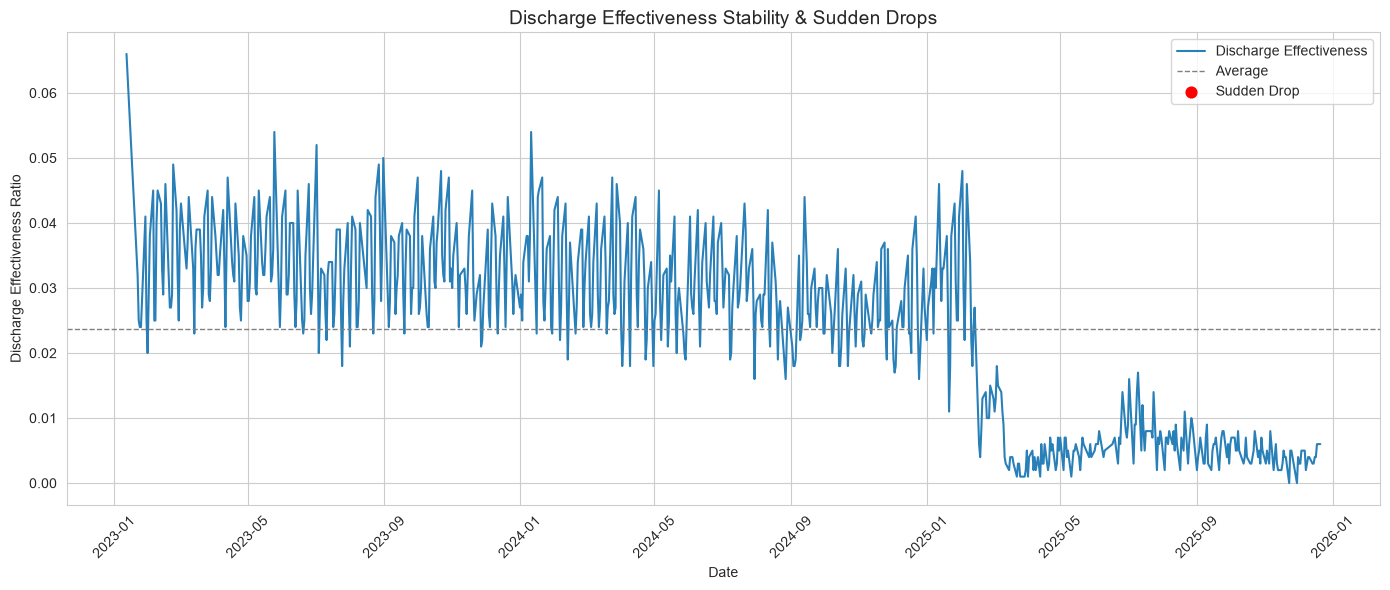

In [36]:
# Visualize discharge effectiveness with sudden drops highlighted
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['Date'], df['discharge_effectiveness'], color='#2980b9', linewidth=1.5, label='Discharge Effectiveness')
ax.axhline(mean_discharge_eff, color='gray', linestyle='--', linewidth=1, label='Average')
ax.scatter(sudden_drops['Date'], sudden_drops['discharge_effectiveness'], color='red', s=60, zorder=5, label='Sudden Drop')

ax.set_title('Discharge Effectiveness Stability & Sudden Drops', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Discharge Effectiveness Ratio')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Month-to-month standard deviation of discharge effectiveness: 0.012


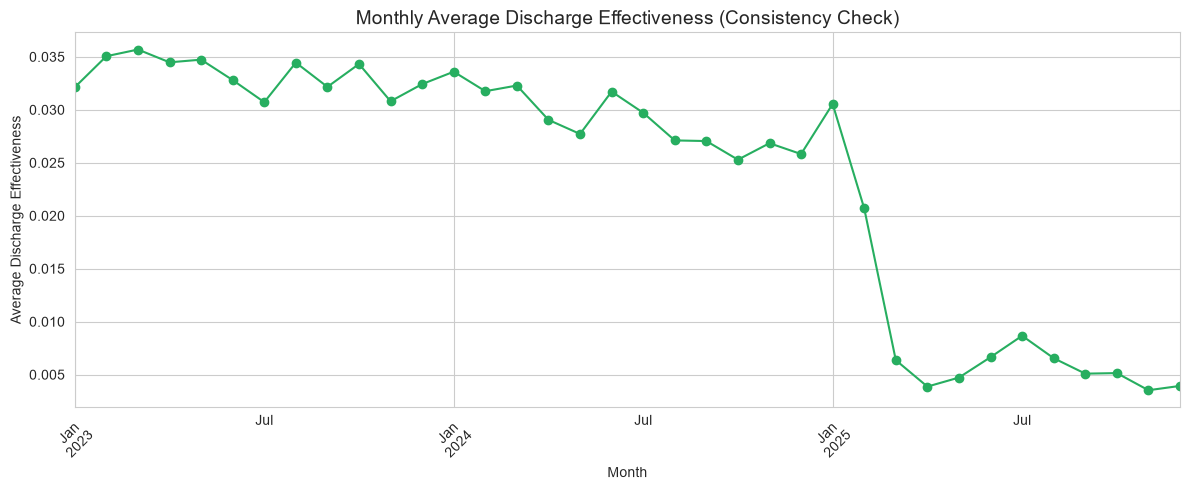

In [ ]:
# Month-to-month consistency: how much does the monthly average discharge rate swing?
monthly_discharge_eff = df.groupby('year_month')['discharge_effectiveness'].mean()
monthly_volatility = monthly_discharge_eff.std()

print(f"Month-to-month standard deviation of discharge effectiveness: {monthly_volatility:.3f}")
monthly_discharge_eff.plot(kind='line', marker='o', figsize=(12, 5), color='#27ae60')
plt.title('Monthly Average Discharge Effectiveness (Consistency Check)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Discharge Effectiveness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Summary: Translating Analysis into Findings

Once you run this notebook against your real dataset, fill in this section with plain-English answers, for example:

- **Transfer efficiency**: "On average, X% of children in CBP custody are transferred to HHS daily. This ratio drops on [weekends/specific months], suggesting a [staffing/procedural] bottleneck at the CBP-to-HHS handoff."
- **Discharge pace**: "Discharges [kept pace with / lagged behind] HHS inflows for X% of the observed period. Sustained backlog episodes averaged Y days."
- **Backlog hotspots**: "The longest backlog episode ran from [Date] to [Date], driven by [rising intake / falling discharge capacity]."
- **Outcome trend**: "Placement outcomes [improved / declined / stayed flat] over the period, with a coefficient of variation of X, indicating [stable / volatile] month-to-month performance. Z sudden-drop days were detected, concentrated around [Dates/events]."

### Suggested next steps
1. Segment the analysis by intake facility or region, if that data is available, to localize bottlenecks.
2. Layer in external events (policy changes, court holidays, staffing changes) to explain spikes/drops.
3. Build a simple monthly dashboard from the metrics computed here (`transfer_efficiency_ratio`, `discharge_effectiveness`, `pipeline_throughput_rate`) for ongoing monitoring, rather than a one-off analysis.
